# Explanation

This notebook is gonna be a first of a series of notebooks for the Value Investing Machine Learning project to establish a baseline as a iteration zero for future reference.

Further explanation of the value investing project can be found in the docs -> Domain analysis document

# Initial Setup

Below is the install command for the needed libraries to run the notebook

pip install scipy scikit-learn pandas seaborn shap


In [1]:
import io, math
from scipy.io import arff
from sklearn.metrics import max_error
from sklearn.metrics import mean_squared_error

import sklearn
import pandas as pd
import seaborn
import shap

import numpy as np

c:\Users\A\OneDrive - Office 365 Fontys\Value-Investing\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data provisioning

The dataset consist of 28 columns. Ranging from 7 million to 22 million rows per column, with a total file size of 3.6gb. This immediately shows a processing problem where trying to do anything with the dataset requires alot of compute.

We can try and tackle this. By limiting the columns we actually need from the dataset. For now we gonna just take the colums that have been mentioned in the expert interview or are most closely related.

Also for these columns we dont need to load in all rows. Since the dataset contains a span of 20 years. So ideally we only want to take more recent data. For example the past 3 years.

While doing this we are gonna try and create a new filtered dataset. Consisting of fewer column and only past data rows of 3 years. That filtered dataset we will use further for our model.

# Data Dictionary
Identifiers  
Ticker: Company trading symbol  
Date: Date of the observation (price + ratios)  

Price / Market  
Adjusted Close (Target Variable): Realistic price including dividends and splits. Used for return calculations.  
Volume: Indicates market activity and sentiment around a stock.  
Market Cap: Company size. Smaller companies may have more pricing inefficiencies.  

Valuation (Core for value investing)  
P/E (ttm): Price relative to earnings. Used to assess how expensive a company is.  
P/S (ttm): Price relative to revenue. Useful when earnings are less reliable.  
P/B: Price relative to assets. Classic value investing metric.  
P/FCF (ttm): Price relative to free cash flow.  
EV/EBITDA: Measures value based on operational cash flow. Widely used by professionals.  
EV/Sales: Alternative valuation when profits are unstable.  

Value Signal  
Book to Market Value: Inverse of P/B. Indicates how “cheap” a stock is relative to its assets.  

Quality (avoid value traps).  
Operating Income/EV: Measures profitability relative to company value.  
Altman Z Score: Financial health indicator. Helps detect risk of bankruptcy.  


Optional  
Dividend Yield: Income return from dividends.  
Stakeholder mentioned dividend as an important anchor in valuation shows reliability of company.  

Data Choice  
The dataset contains both quarterly and yearly (TTM) data we will use past data of 3 years.  
For this model, TTM data is used because:

It reduces short-term noise  
It better reflects long-term earning capacity  
It aligns with how the stakeholder evaluates companies with long term vision in mind.  

In [2]:
#data column selection only exectued once to select columns
if False:
    df = pd.read_csv("../Dataset/us-derived-shareprices-daily.csv", sep=";")
    df.columns = df.columns.str.strip()

    print(df.columns.tolist())

Make sure we select the right columns from the initial dataset.

In [3]:
# Data filtering step (executed once to create smaller working dataset)
if False:

    # columns we want to use
    cols = [
        "Ticker", 
        "Date", 
        "Adj. Close", 
        "Volume", 
        "Market-Cap",
        "Price to Earnings Ratio (ttm)",
        "Price to Sales Ratio (ttm)",
        "Price to Book Value",
        "Price to Free Cash Flow (ttm)",
        "EV/EBITDA", 
        "EV/Sales",
        "Book to Market Value",
        "Operating Income/EV",
        "Altman Z Score",
        "Dividend Yield"
    ]

    # load only selected columns
    df = pd.read_csv(
        "us-derived-shareprices-daily/us-derived-shareprices-daily.csv",
        usecols=cols,
        sep=";"
    )

    # convert Date column
    df["Date"] = pd.to_datetime(df["Date"])

    # filter between 2022 and end of 2025
    df = df[df["Date"].between("2022-01-01", "2025-12-31")]

    # save filtered dataset
    df.to_csv("filtered_shares_ratios_3years.csv", index=False)

    print("created filtered dataset")


df = pd.read_csv("../filtered_shares_ratios_3years.csv")
df.describe()


,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield
count,5.077223e+06,5.077223e+06,4.846845e+06,3.619868e+06,3.274182e+06,4.048688e+06,2.758179e+06,3.212294e+06,3.200910e+06,3.972041e+06,3.577781e+06,2.859125e+06,1.636477e+06
mean,2.508054e+04,1.703947e+06,4.219712e+12,-1.730331e+01,1.370486e+02,1.063825e+01,-2.022930e+01,1.040932e+00,7.648980e+01,1.096683e+01,-8.269594e+00,2.341573e+01,2.185915e+00
std,1.419652e+06,1.106200e+07,4.197879e+14,2.812195e+03,3.520416e+03,1.900016e+03,2.239674e+03,1.370573e+03,3.095022e+03,8.267660e+02,9.473802e+02,2.024572e+03,2.855518e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-3.576344e+04
25%,5.780000e+00,3.290600e+04,1.301741e+08,-3.799602e+00,7.373900e-01,7.864400e-01,-2.938540e+00,-7.300700e-01,8.751400e-01,1.875300e-01,-5.040000e-02,6.364500e-01,1.068000e-02
50%,1.626000e+01,2.620240e+05,7.850186e+08,6.453625e+00,1.953155e+00,1.616180e+00,5.291540e+00,7.518780e+00,2.221115e+00,4.889800e-01,3.346000e-02,2.211520e+00,2.341000e-02
75%,4.615000e+01,1.039564e+06,4.506176e+09,2.126395e+01,4.593700e+00,3.642730e+00,1.524451e+01,1.497710e+01,5.223825e+00,9.737800e-01,8.125000e-02,4.288110e+00,4.275000e-02
max,1.000000e+08,5.497020e+09,5.698460e+16,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,2.414675e+04


In this describe even if it is in scientific notation. We can already cleary see in the min and max values huge discrepencies. We have 0 values, as well as huge values seen by the amount of zeros added to some max values.

This suggest that the dataset contains extreme outliers, as well as unusable values for training a model.

# GitIgnore

Created a filtered dataset reduced from 28 to 15 columns.

Since the datasets are to big to push to github and don't belong in github. Added datasets .csv, .parquet, .xslx files to gitignore.

In [5]:
df.sample(5)

,Ticker,Date,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield
2456949,IVR,2025-02-07,6.95,1065548,5.277462e+08,7.04233,1.61549,0.51371,NaN,-20.36109,-19.79394,1.94662,-0.04918,-0.3995,0.22896
792407,CAAS,2023-12-05,3.13,24410,1.128945e+08,3.64277,0.20761,0.32454,0.54874,0.23729,0.11692,3.08128,3.87842,NaN,NaN
4582323,TUYA,2022-11-14,0.90,460501,5.598216e+08,NaN,NaN,0.19534,NaN,NaN,NaN,5.11928,NaN,NaN,NaN
563600,BCRX,2023-08-01,6.97,3732560,1.318152e+09,-5.54573,4.33143,-3.82208,-7.07337,-9.26079,4.00764,-0.26164,-0.10930,-2.4900,NaN
2435245,ISPR,2023-04-25,7.89,19258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Here is a random sample taken from the data which confirms our earlier idea. We can see alot of missing or unusable values as well as very fluctuating values. Since this is the baseline model we won't dive into fixing this.

In [8]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Dividend Yield                   67.768266
Price to Free Cash Flow (ttm)    45.675441
Altman Z Score                   43.687228
EV/Sales                         36.955497
EV/EBITDA                        36.731280
Price to Sales Ratio (ttm)       35.512346
Operating Income/EV              29.532719
Price to Earnings Ratio (ttm)    28.703782
Book to Market Value             21.767450
Price to Book Value              20.257826
Market-Cap                        4.537480
Ticker                            0.017194
Adj. Close                        0.000000
Date                              0.000000
Volume                            0.000000
log_adj_close                     0.000000
dtype: float64

Here we see for each feature the percentage amount of missing values. It's clear that for most values this a way to high number to use in this state for training a model.

# Preprocessing

Since the dataset is full of outliers, huge differences in values, and missing values or unusable values, as well as text values. This imposes challenging but interesting work for making the dataset suitable for a machine learning model. Since this is still the baseline model, we will keep preprocessing for now as minimally as possible to be able to use the dataset.

In [9]:
ratio_cols = [
    "Price to Earnings Ratio (ttm)",
    "Price to Sales Ratio (ttm)",
    "Price to Book Value",
    "Price to Free Cash Flow (ttm)",
    "EV/EBITDA",
    "EV/Sales",
    "Book to Market Value",
    "Operating Income/EV",
    "Altman Z Score",
    "Dividend Yield"
]

ticker_quality = (
    df.groupby("Ticker")[ratio_cols]
      .apply(lambda x: x.notna().mean().mean())
      .sort_values(ascending=False)
)

print(ticker_quality)

Ticker
ZEUS    1.0
ZBH     1.0
ABBV    1.0
AAPL    1.0
YUM     1.0
       ... 
KRNT    0.0
EE      0.0
JSPR    0.0
STG     0.0
ZWS     0.0
Length: 5793, dtype: float64


In [10]:
print("Companies with >= 90% completeness:",
      (ticker_quality >= 0.90).sum())

print("Companies with >= 95% completeness:",
      (ticker_quality >= 0.95).sum())

print("Companies with 100% completeness:",
      (ticker_quality == 1.00).sum())

print("Total companies:", df["Ticker"].nunique())

Companies with >= 90% completeness: 2062
Companies with >= 95% completeness: 844
Companies with 100% completeness: 681
Total companies: 5793


In [11]:
complete_tickers = ticker_quality[ticker_quality == 1.0].index.tolist()

print(complete_tickers)
print("Number of complete companies:", len(complete_tickers))

['ZEUS', 'ZBH', 'ABBV', 'AAPL', 'YUM', 'XYL', 'XRX', 'XRAY', 'XPER', 'XOM', 'XLNX', 'XHR', 'WYNN', 'WWW', 'WWE', 'WWD', 'WU', 'ACA', 'ABT', 'WTW', 'WTS', 'WST', 'WSM', 'WRK', 'WNC', 'WMT', 'WMS', 'WMG', 'WMB', 'WM', 'WLFC', 'WIRE', 'WING', 'WINA', 'WHR', 'WHG', 'ACC', 'WHD', 'WGO', 'WEYS', 'WERN', 'WEN', 'WELL', 'WEC', 'WDFC', 'WCN', 'WCC', 'WBA', 'WAB', 'ACN', 'VTRS', 'VST', 'VSEC', 'VRTS', 'VRT', 'VRSK', 'VRS', 'VNT', 'VNO', 'VMI', 'VMC', 'VICI', 'VCTR', 'VATE', 'V', 'UTZ', 'UTMD', 'USLM', 'USG', 'UPS', 'UNP', 'UNH', 'UNF', 'ULH', 'UI', 'UHAL', 'UGI', 'UFPI', 'TXRH', 'TXN', 'TTEK', 'TTEC', 'TTC', 'TT', 'ADP', 'ADI', 'ADES', 'TSN', 'TSCO', 'TRU', 'TRTN', 'TRP', 'TROX', 'TROW', 'TRGP', 'TRCY', 'TR', 'AEE', 'AE', 'TOL', 'TNL', 'TNC', 'TMO', 'TM', 'TKR', 'TJX', 'TILE', 'THO', 'TGT', 'TGLS', 'TER', 'TEL', 'TECH', 'TDG', 'TAP', 'TACO', 'SYY', 'SYK', 'SXT', 'SXC', 'SWM', 'SWKS', 'SWK', 'SWI', 'SWCH', 'SWBI', 'SVC', 'SUP', 'STZ', 'STX', 'AGFS', 'AGCO', 'STRA', 'STOR', 'STLD', 'STE', 'SSTK', 

In [12]:
print(ticker_quality.sample(20))

Ticker
SKYT    0.900000
NKLA    0.782256
ORRF    0.328116
TDG     1.000000
BLND    0.817448
ETON    0.187637
FI      0.900000
DASH    0.816451
XPL     0.137488
VFS     0.000000
LIPO    0.615385
RAIN    0.600000
MDRX    0.900000
RMR     0.330409
CRUS    0.900000
AVAC    0.400000
BRO     0.891127
SIGI    0.563709
S       0.859521
DMYS    0.177215
dtype: float64


Here you can see how much difference there is in the dataset in completness of the data per company

In [13]:
good_tickers = ticker_quality[ticker_quality >= 0.90].index

df_good = df[df["Ticker"].isin(good_tickers)]

print("Companies:", df_good["Ticker"].nunique())
print("Rows:", len(df_good))

Companies: 2062
Rows: 1796191


In [14]:
(df_good.isnull().sum() / len(df_good) * 100).sort_values(ascending=False)

Dividend Yield                   46.957478
Altman Z Score                    5.948477
Price to Free Cash Flow (ttm)     2.030519
EV/EBITDA                         0.617807
EV/Sales                          0.290893
Operating Income/EV               0.286439
Book to Market Value              0.269403
Price to Book Value               0.238282
Price to Earnings Ratio (ttm)     0.069703
Price to Sales Ratio (ttm)        0.062521
Market-Cap                        0.004287
Volume                            0.000000
Ticker                            0.000000
Date                              0.000000
Adj. Close                        0.000000
log_adj_close                     0.000000
dtype: float64

In [ ]:
X = df_good.drop(columns=["Adj. Close","log_adj_close"])
y = df_good["Adj. Close"]

['Ticker', 'Date', 'Adj. Close', 'Volume', 'Market-Cap', 'Price to Earnings Ratio (ttm)', 'Price to Sales Ratio (ttm)', 'Price to Book Value', 'Price to Free Cash Flow (ttm)', 'EV/EBITDA', 'EV/Sales', 'Book to Market Value', 'Operating Income/EV', 'Altman Z Score', 'Dividend Yield', 'log_adj_close']


In [16]:
company_df = df_good.groupby("Ticker").last()
df_good = df_good.drop(columns=["Date", "Ticker","Dividend Yield"])


corr = company_df.corr(numeric_only=True)["Adj. Close"]

print(corr.sort_values())

Volume                          -0.006352
Price to Sales Ratio (ttm)      -0.001399
EV/Sales                        -0.001273
Price to Book Value             -0.000902
Book to Market Value            -0.000397
Operating Income/EV             -0.000391
Price to Earnings Ratio (ttm)   -0.000382
Altman Z Score                   0.000553
EV/EBITDA                        0.000744
Price to Free Cash Flow (ttm)    0.001685
Dividend Yield                   0.035076
Market-Cap                       0.117756
log_adj_close                    0.155255
Adj. Close                       1.000000
Name: Adj. Close, dtype: float64


In [18]:
#Check if all columns are the right datatypes
print(df_good.dtypes)

Adj. Close                       float64
Volume                             int64
Market-Cap                       float64
Price to Earnings Ratio (ttm)    float64
Price to Sales Ratio (ttm)       float64
Price to Book Value              float64
Price to Free Cash Flow (ttm)    float64
EV/EBITDA                        float64
EV/Sales                         float64
Book to Market Value             float64
Operating Income/EV              float64
Altman Z Score                   float64
log_adj_close                    float64
dtype: object


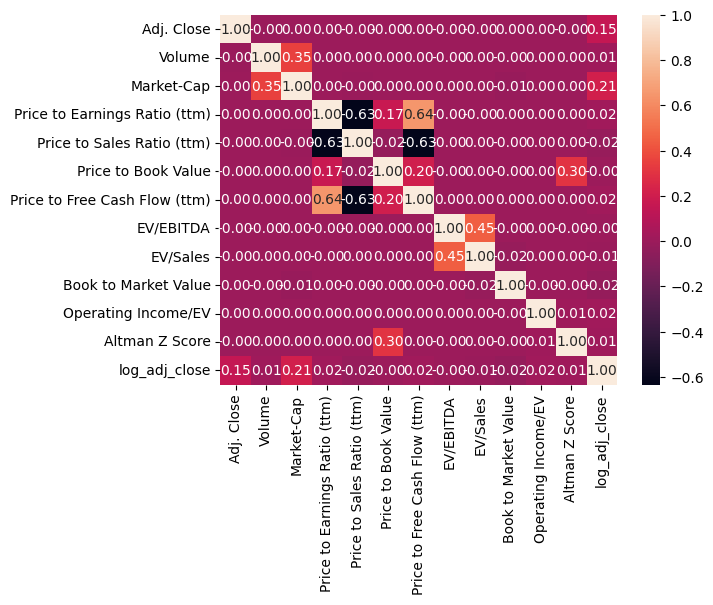

In [17]:
correlations = df_good.corr()
plot = seaborn.heatmap(correlations, cbar=True, annot=True, fmt=".2f")

# Correlation Matrix with Target variable
In this correlation matrix it shows that the target variable has very weak correlations with the other features. In general all of the features are very weak to none correlation. 

However this correlation matrix does not support or domain analysis. This dataset with its features was selected based on the stakeholders input how they analyze businesses and what they look at for stock prices. Since the stakeholder runs a succesfull investment firm and these practices they've applied for many years.

We make the hypothesis that this correlation matrix doesn't accurately represent the features correlations. And there might be an issue in the dataset.

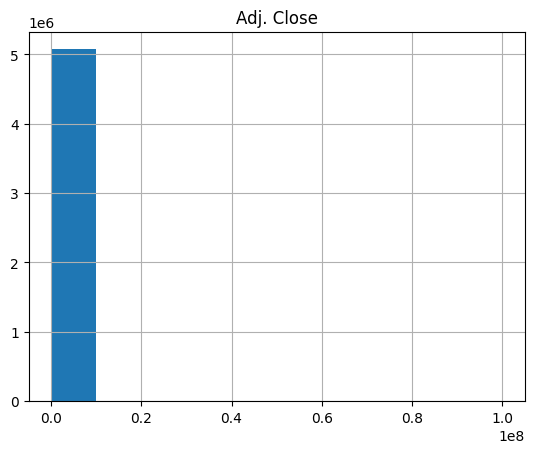

In [ ]:
plot = df.hist(column="Adj. Close")

<Axes: >

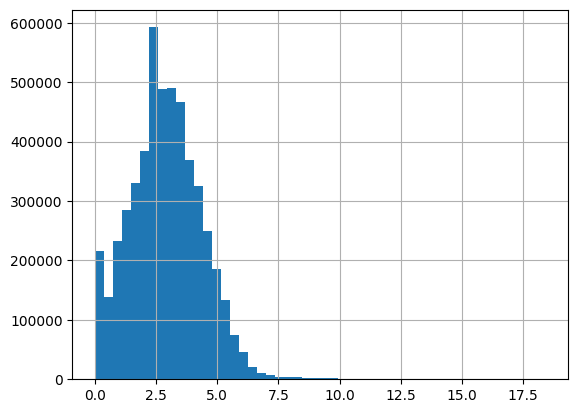

In [ ]:
df["log_adj_close"] = np.log1p(df["Adj. Close"])
df["log_adj_close"].hist(bins=50)

Since the current dataset contains so many missing or unreliable values like -100.000 / 100.000. Or is just heavily influenced by the huge differences between prices. Producing any visually usable graph without logging is impossible. So we log the data to make the target variable visually understandable.

We can see the data is lightly skewed but mostly normally distributed.

In [19]:
for col in df_good.select_dtypes(include=["number"]).columns:
    print(f"\n=== {col} ===")
    print(df_good[col].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99, 0.999]))

    print("\nTop 10 values:")
    print(df_good[col].sort_values(ascending=False).head(10))

    print("\nBottom 10 values:")
    print(df_good[col].sort_values().head(10))


=== Adj. Close ===
count    1.796191e+06
mean     1.200725e+04
std      7.959814e+05
min      0.000000e+00
1%       7.400000e-01
5%       2.540000e+00
50%      3.173000e+01
95%      2.809350e+02
99%      6.124410e+02
99.9%    9.424680e+03
max      8.043840e+07
Name: Adj. Close, dtype: float64

Top 10 values:
4897143    80438400.0
4897203    80136000.0
4897141    79228800.0
4897142    78926400.0
4897140    78624000.0
4897144    78022224.0
4897162    77871024.0
4897155    77716800.0
4897159    77716800.0
4897158    76809600.0
Name: Adj. Close, dtype: float64

Bottom 10 values:
4247574    0.0
4247573    0.0
4247572    0.0
4247603    0.0
4247602    0.0
4247601    0.0
4247600    0.0
4247610    0.0
4247773    0.0
4247627    0.0
Name: Adj. Close, dtype: float64

=== Volume ===
count    1.796191e+06
mean     2.445955e+06
std      1.326609e+07
min      0.000000e+00
1%       1.600000e+02
5%       1.090400e+04
50%      5.509920e+05
95%      8.443886e+06
99%      3.042888e+07
99.9%    1.346886e+0

Shows that the entire dataset each feature contains extreme outlier and placeholder values for NaN values making the dataset unusable in it's current state.

# Workaround


You can also try and work the other way around instead of arbitraly cleaning up ur dataset. Since this is the baseline model I'll keep it short but in the, preprocessing notebook you can see my attempts at cleaning the dataset, and how I pivoted to looking for right data instead of wrong data. 

You can just look in the dataset for companies that contain all financial ratios and data. and then just use those companies for the modeling.

In [20]:
df_trim = df_good.copy()

df_trim.drop(
    columns=["log_adj_close"],
    errors="ignore"
).copy()

numeric_cols = df_trim.select_dtypes(include=["number"]).columns

for col in numeric_cols:

    lower = df_trim[col].quantile(0.01)
    upper = df_trim[col].quantile(0.99)

    df_trim = df_trim[
        (df_trim[col] >= lower) &
        (df_trim[col] <= upper)
    ]

print("Original shape:", df_good.shape)
print("Trimmed shape:", df_trim.shape)

Original shape: (1796191, 13)
Trimmed shape: (1270918, 13)


Here we arbitrarly eliminate bottom and top 0,5% of the dataset to remove extreme values

In [21]:
corr_original = (
    df_good
    .corr(numeric_only=True)["Adj. Close"]
    .sort_values()
)

corr_trimmed = (
    df_trim
    .corr(numeric_only=True)["Adj. Close"]
    .sort_values()
)

print("ORIGINAL")
print(corr_original)

print("\nTRIMMED")
print(corr_trimmed)

ORIGINAL
Volume                          -0.002765
Price to Sales Ratio (ttm)      -0.000432
EV/EBITDA                       -0.000189
Altman Z Score                  -0.000116
EV/Sales                        -0.000114
Price to Book Value             -0.000102
Market-Cap                       0.000029
Price to Earnings Ratio (ttm)    0.000057
Price to Free Cash Flow (ttm)    0.000129
Book to Market Value             0.000772
Operating Income/EV              0.001447
log_adj_close                    0.154385
Adj. Close                       1.000000
Name: Adj. Close, dtype: float64

TRIMMED
Book to Market Value            -0.329057
Volume                          -0.058220
Operating Income/EV              0.103833
Price to Free Cash Flow (ttm)    0.136261
Price to Earnings Ratio (ttm)    0.150149
EV/EBITDA                        0.155295
Price to Book Value              0.220241
EV/Sales                         0.262653
Altman Z Score                   0.264218
Price to Sales Ratio (ttm

In [22]:
print(
    corr_original.abs().sort_values(ascending=False)
)

Adj. Close                       1.000000
log_adj_close                    0.154385
Volume                           0.002765
Operating Income/EV              0.001447
Book to Market Value             0.000772
Price to Sales Ratio (ttm)       0.000432
EV/EBITDA                        0.000189
Price to Free Cash Flow (ttm)    0.000129
Altman Z Score                   0.000116
EV/Sales                         0.000114
Price to Book Value              0.000102
Price to Earnings Ratio (ttm)    0.000057
Market-Cap                       0.000029
Name: Adj. Close, dtype: float64


In [23]:
print(
    corr_trimmed.abs().sort_values(ascending=False)
)

Adj. Close                       1.000000
log_adj_close                    0.839404
Market-Cap                       0.420391
Book to Market Value             0.329057
Price to Sales Ratio (ttm)       0.285223
Altman Z Score                   0.264218
EV/Sales                         0.262653
Price to Book Value              0.220241
EV/EBITDA                        0.155295
Price to Earnings Ratio (ttm)    0.150149
Price to Free Cash Flow (ttm)    0.136261
Operating Income/EV              0.103833
Volume                           0.058220
Name: Adj. Close, dtype: float64


In [26]:
for col in df_trim.columns:
    print(f"\n{'='*60}")
    print(col)
    print('='*60)

    print(
        df_trim[col].describe(
            percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
        )
    )


Adj. Close
count    1.270918e+06
mean     6.540419e+01
std      7.832192e+01
min      1.650000e+00
1%       2.220000e+00
5%       4.140000e+00
25%      1.380000e+01
50%      3.477000e+01
75%      8.540000e+01
95%      2.312100e+02
99%      3.828600e+02
max      4.656100e+02
Name: Adj. Close, dtype: float64

Volume
count    1.270918e+06
mean     1.682717e+06
std      3.193864e+06
min      3.780000e+02
1%       3.529170e+03
5%       2.485200e+04
25%      1.993710e+05
50%      6.008240e+05
75%      1.631790e+06
95%      7.284495e+06
99%      1.739192e+07
max      3.060176e+07
Name: Volume, dtype: float64

Market-Cap
count    1.270918e+06
mean     1.324201e+10
std      2.995099e+10
min      1.762275e+07
1%       4.419178e+07
5%       1.221693e+08
25%      7.722075e+08
50%      2.746677e+09
75%      1.013538e+10
95%      6.600659e+10
99%      1.700777e+11
max      2.481752e+11
Name: Market-Cap, dtype: float64

Price to Earnings Ratio (ttm)
count    1.270918e+06
mean     1.463009e+01
std   

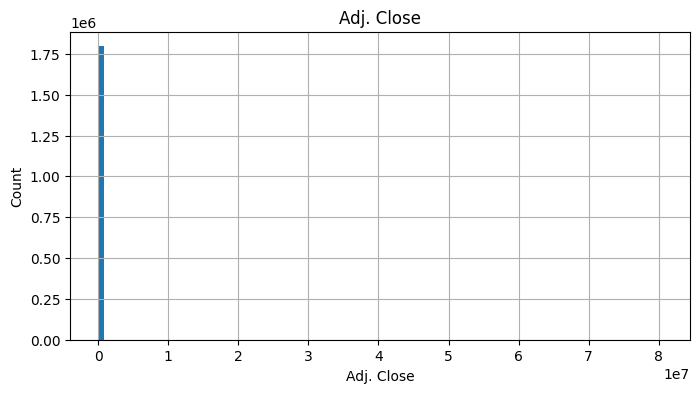

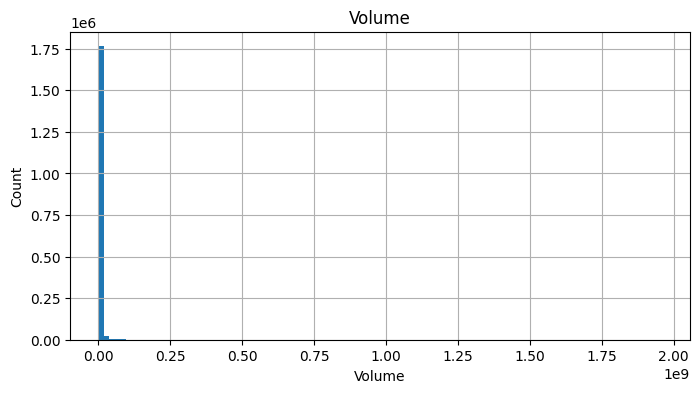

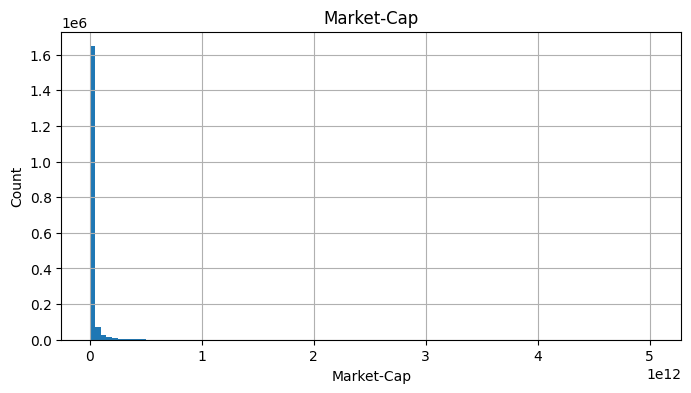

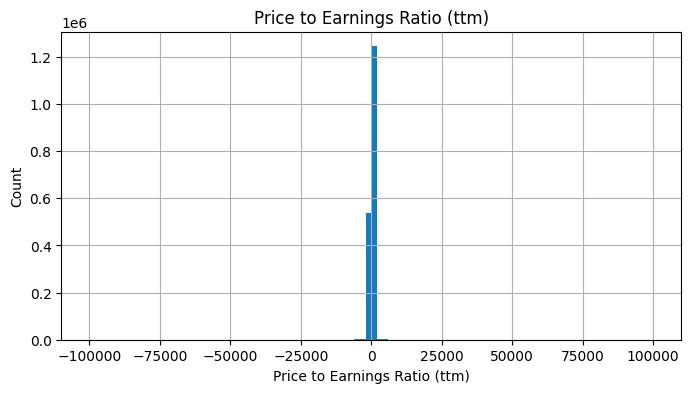

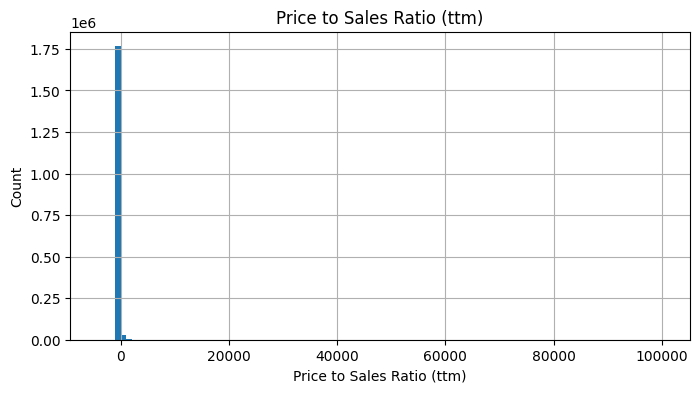

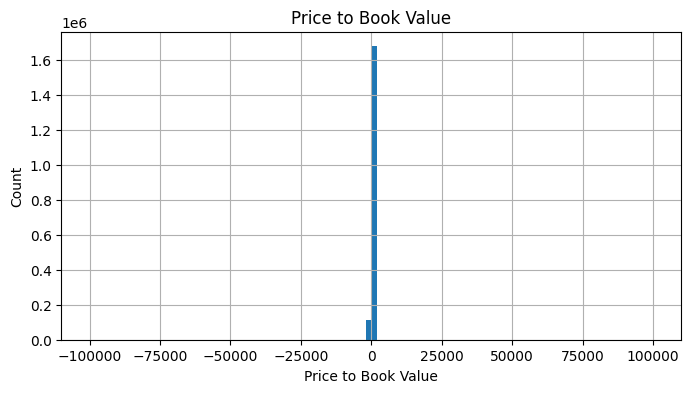

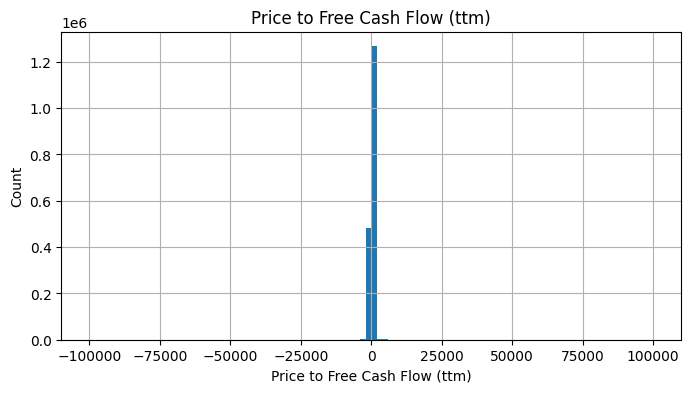

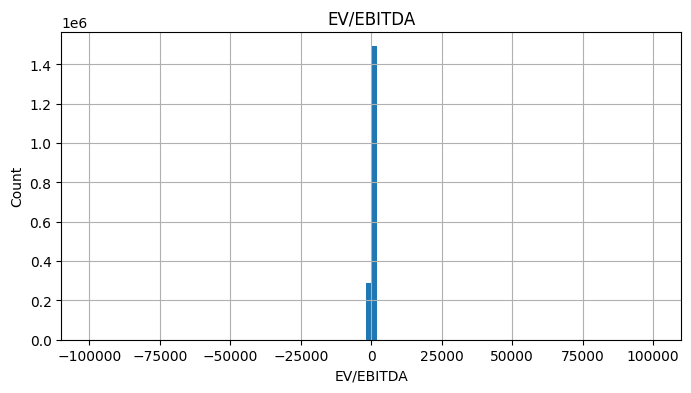

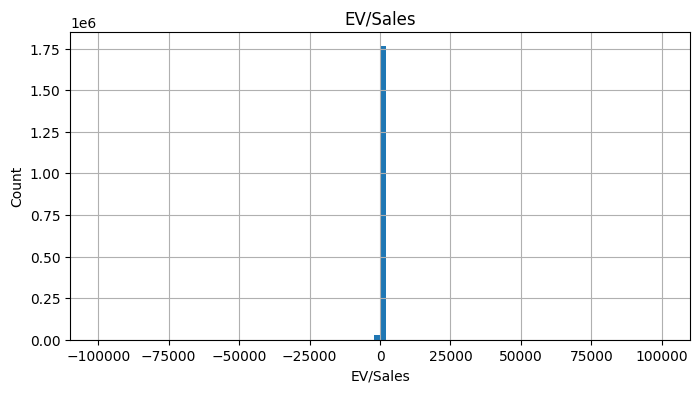

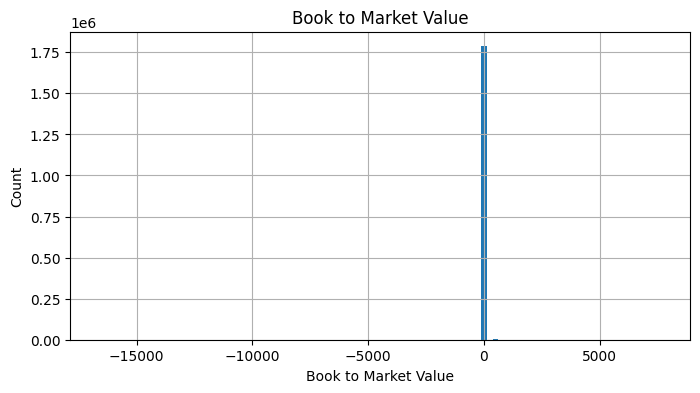

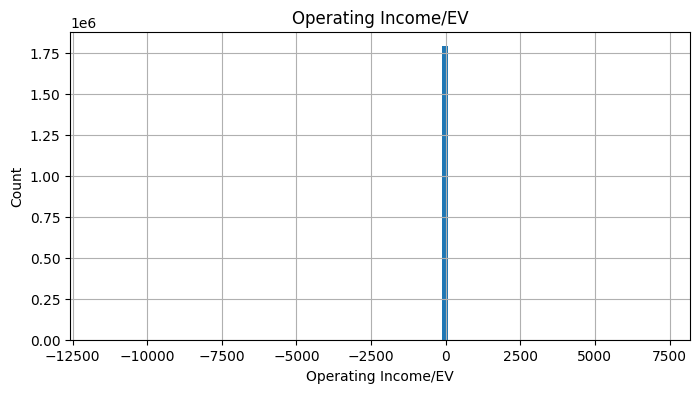

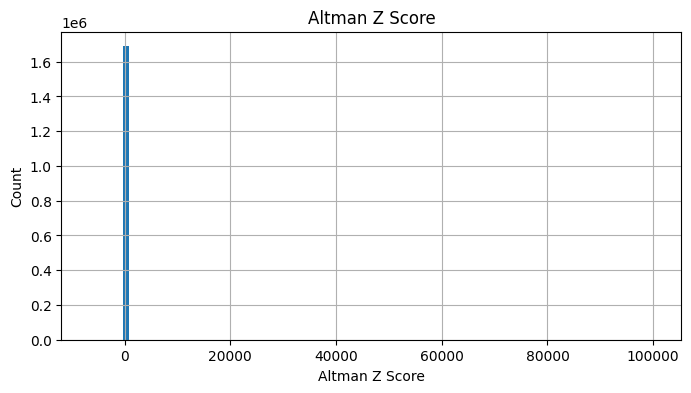

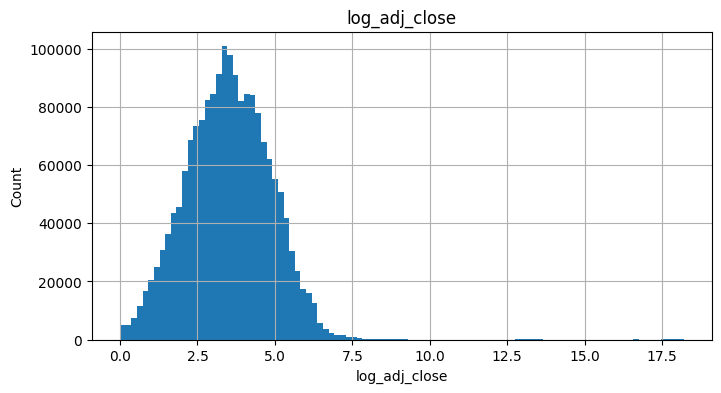

In [31]:
import matplotlib.pyplot as plt

for col in df_good.columns:

    plt.figure(figsize=(8, 4))

    df_good[col].hist(
        bins=100
    )

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()


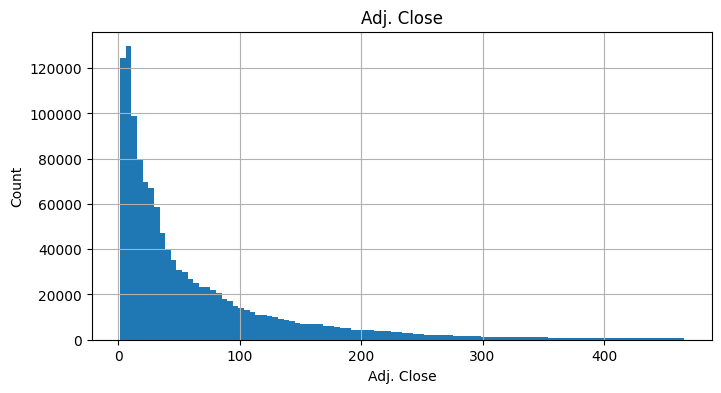

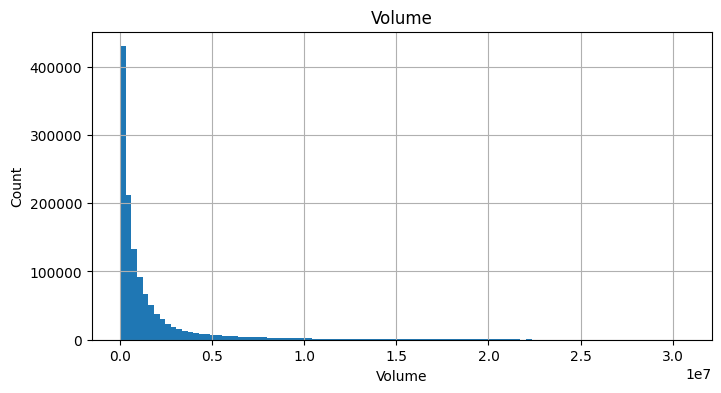

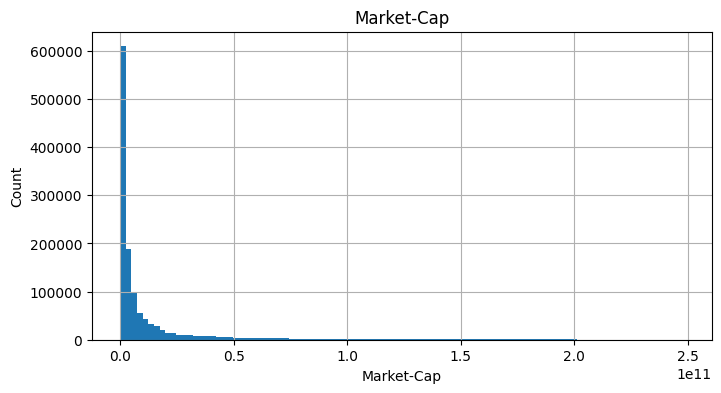

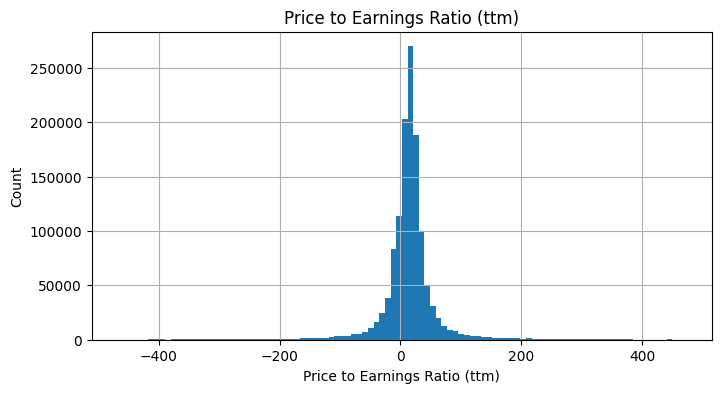

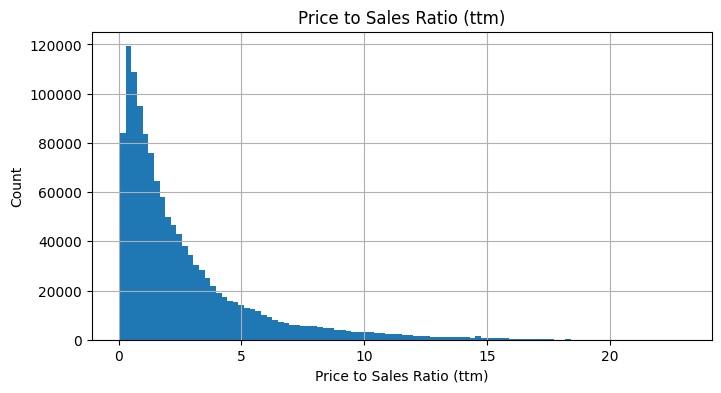

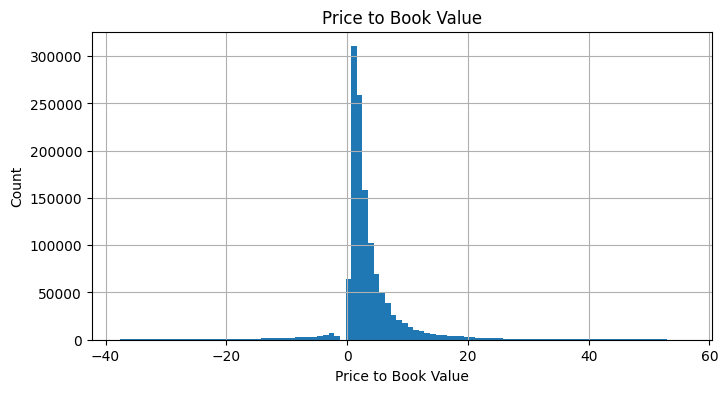

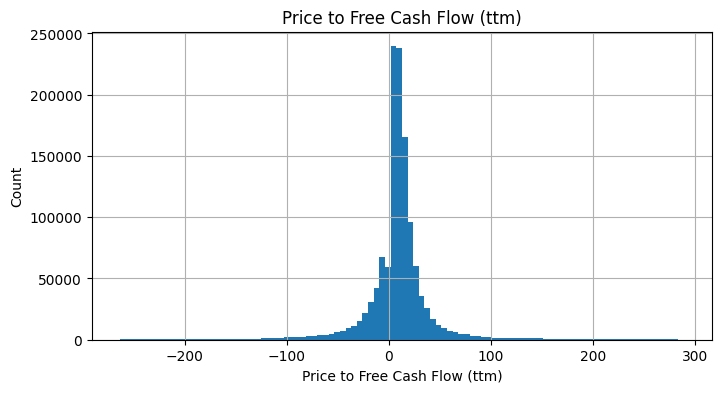

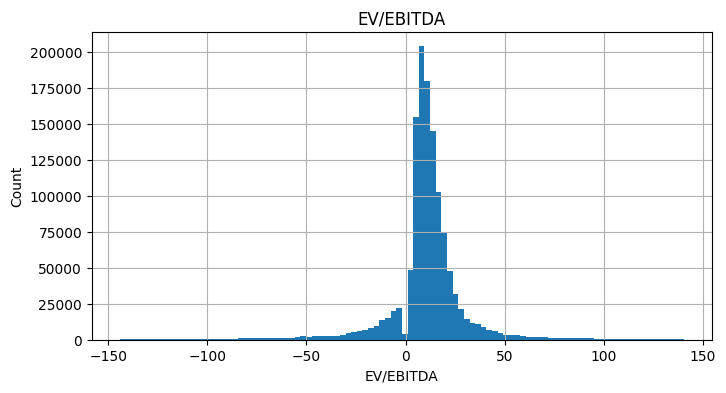

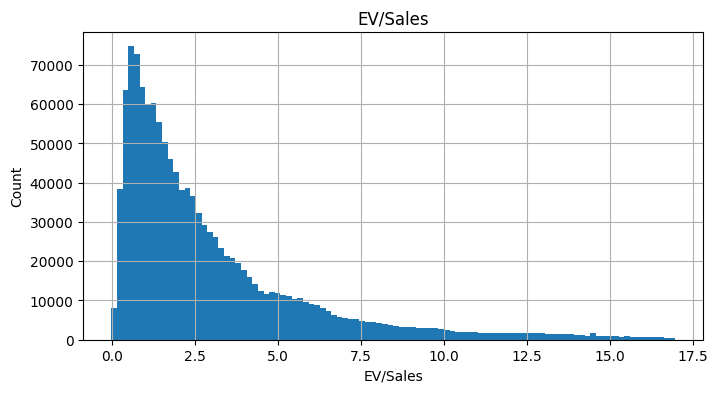

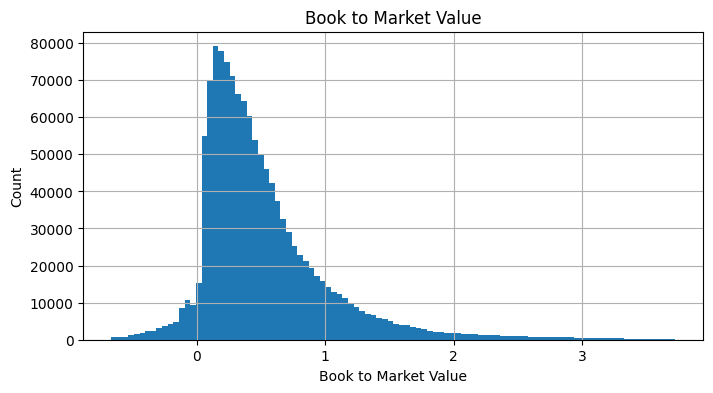

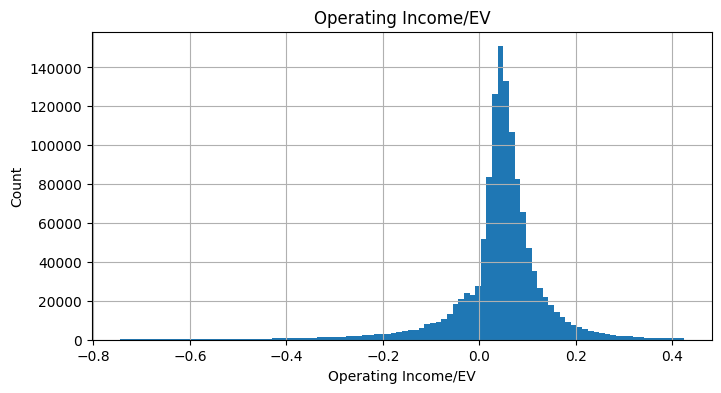

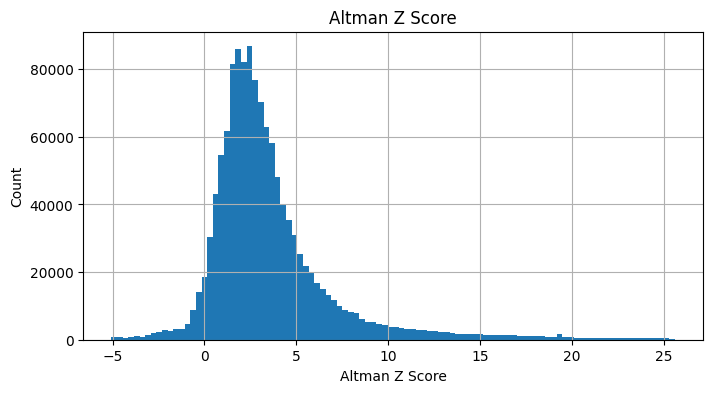

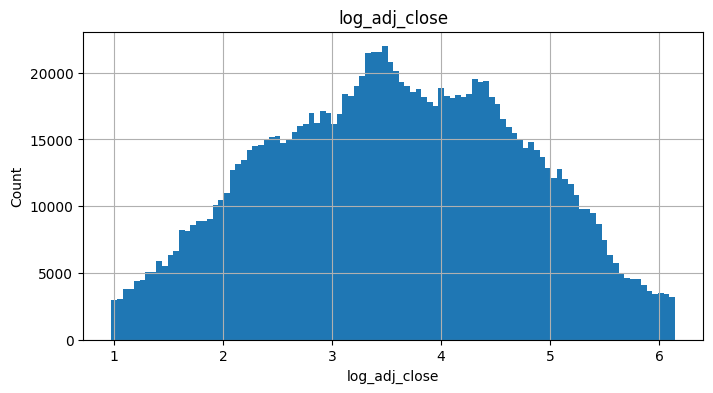

In [32]:

for col in df_trim.columns:

    plt.figure(figsize=(8, 4))

    df_trim[col].hist(
        bins=100
    )

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

Above you can see difference in the graphs distributions from the dataframe before and after the cleaning and selection. There are a couple of valuable observations, of weird behaviour.

1. We can see that the range of values dramatically decreases

2. We can see alot of features are heavily skewed which is normal and inline with what we expected.

3. Ideally we would like to see even curves in the graphs indicating a spreaded distribitution. However in some features graphs we still see some unexplainable fluctuations that require further investigation. Like drops around the 0 value.

4. This is also strange since for some graphs we wouldn't expect 0 values but they still contain them and some of them quite alot.

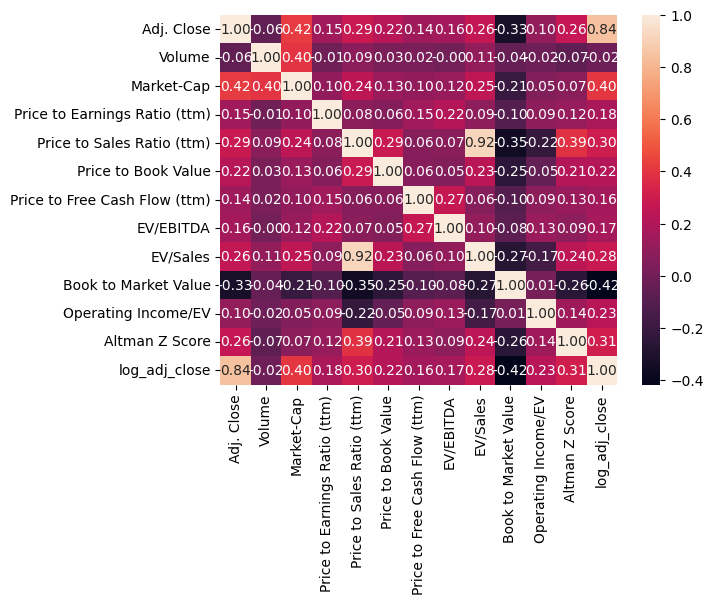

In [28]:
correlations = df_trim.corr()
plot = seaborn.heatmap(correlations, cbar=True, annot=True, fmt=".2f")

In [36]:
corr = df_trim.corr(numeric_only=True)["Adj. Close"]

print(corr.abs().sort_values(ascending=False).head(10))

Adj. Close                       1.000000
log_adj_close                    0.839404
Market-Cap                       0.420391
Book to Market Value             0.329057
Price to Sales Ratio (ttm)       0.285223
Altman Z Score                   0.264218
EV/Sales                         0.262653
Price to Book Value              0.220241
EV/EBITDA                        0.155295
Price to Earnings Ratio (ttm)    0.150149
Name: Adj. Close, dtype: float64


Above we see the top correlations with our target variable. Market-cap, book to market, p/s ratio, altman z score, ev/sales. Are the features we're 

# Data cleaning and Pre processing notebook

Since this is the baseline model we don't dive to deep into our research how we got to these solutions. However coming to these conclusions took extensive hypothesis and experimentation to confirm the hypothesis which is covered in the Data cleaning and pre processing notebook.

# Model trainen

Model trainen op 2 verschillende feature sets een keer alle features en een keer alle features arbitrair boven 0.25